# RetailCo Demand Model — Experimentos e Evidências

Este notebook contém toda a investigação técnica por trás da correção do modelo de forecast do RetailCo, organizada **por pergunta respondida**, não em ordem cronológica de execução. Serve como fonte de evidência para qualquer pergunta técnica da banca.

**Seções:**
1. Carregar dados e engenharia de features
2. Diagnóstico do Problema 2 (causa raiz do sinal errado do SHAP)
3. Normalização de preço vs restrição monotônica
4. Pooling vs SKU-level
5. Bake-off de modelos (LightGBM, XGBoost, GAM, Ensemble empilhado)
6. Busca bayesiana de hiperparâmetros (Optuna)
7. Validação recursiva (multi-step) e degradação por horizonte
8. Teste de restrição nos modelos vencedores problemáticos

> Testes de significância estatística (elasticidade de preço, Promoção vs Publicidade) estão no notebook separado `Statistical_Significance_Tests.ipynb`.

> Requisitos: `pip install lightgbm xgboost pygam shap optuna pandas numpy scikit-learn matplotlib openpyxl`


## 0. Libraries

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import lightgbm as lgb
import xgboost as xgb
import shap
import optuna
import matplotlib.pyplot as plt
from pygam import LinearGAM, s, l, f
from scipy import stats

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")


C:\Users\ASSURANCE IT\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 0.1. Load Data

Edite `DATA_PATH` abaixo para o caminho do seu arquivo.

In [2]:
DATA_PATH = "Business_Case_Data_Set.xlsx"
OUTDIR = Path("output")
OUTDIR.mkdir(exist_ok=True, parents=True)

CATEGORY_MAP = {
    "Natural Juice 1L": "Beverages",
    "Flavored Water 500ml": "Beverages",
    "Energy Drink 350ml": "Beverages",
    "Whole Grain Crackers 200g": "Snacks",
    "Cereal Bar 50g": "Snacks",
}

xl = pd.ExcelFile(DATA_PATH)
ext = xl.parse("Table 1 - External Variables")
actual = xl.parse("Table 2 - Sell In")

raw = ext.merge(actual, on=["Week", "Product", "Channel"], how="inner")
raw["Week"] = pd.to_datetime(raw["Week"])
raw["Category"] = raw["Product"].map(CATEGORY_MAP)
raw = raw.sort_values(["Product", "Channel", "Week"]).reset_index(drop=True)

# Trend term for the GAM: position (0,1,2,...) within each Product x Channel
# series, computed on the FULL raw series (before feature engineering drops
# the early rows with no lag history).
raw["Week_Index"] = raw.groupby(["Product", "Channel"]).cumcount()

print(f"{len(raw)} rows loaded, {raw['Week'].min().date()} to {raw['Week'].max().date()}")
raw.head()


2340 rows loaded, 2023-07-03 to 2026-06-22


,Week,Product,Channel,Price_per_kg_USD,Numeric_Distribution,Weighted_Distribution,Advertising_Investment_USD,Promotion_Investment_USD,Promotion_Type,Sell_In_Tons,Category,Week_Index
0,2023-07-03,Cereal Bar 50g,E-commerce,11.46,57.4,48.3,8656,4980,NaN,0.872,Snacks,0
1,2023-07-10,Cereal Bar 50g,E-commerce,11.48,60.1,67.3,4773,3765,NaN,0.971,Snacks,1
2,2023-07-17,Cereal Bar 50g,E-commerce,12.42,52.1,42.6,10906,3263,Discount,1.060,Snacks,2
3,2023-07-24,Cereal Bar 50g,E-commerce,12.34,55.7,60.8,9911,3899,NaN,0.974,Snacks,3
4,2023-07-31,Cereal Bar 50g,E-commerce,12.03,64.8,52.9,11007,4754,NaN,1.103,Snacks,4


## 0.2. Feature Engineering

Implementa as 10 regras da Tabela 4 (Feature Engineering Rules).

In [ ]:
TARGET_COL = "Sell_In_Tons"

FEATURE_COLS = [
    "Price_per_kg_USD", "Numeric_Distribution", "Weighted_Distribution",
    "Advertising_Investment_USD", "Promotion_Investment_USD", "Promo_Flag",
    "Lag_1w", "Lag_4w", "Rolling_Mean_4w", "Rolling_Std_4w",
    "Price_Change_Pct", "Month_Sin", "Month_Cos", "Holiday_Flag",
    "Interaction_Price_Promo",
]

FEATURE_COLS_GAM = [
    "Week_Index", "Month_Sin", "Month_Cos", "Price_per_kg_USD",
    "Numeric_Distribution", "Weighted_Distribution", "Advertising_Investment_USD",
    "Promotion_Investment_USD", "Promo_Flag", "Lag_1w", "Price_Change_Pct",
    "Interaction_Price_Promo",
]
FEATURE_COLS_STACKED = list(dict.fromkeys(FEATURE_COLS_GAM + FEATURE_COLS))

#Define the proportion of the data to be used for the holdout test set.
HOLDOUT_QUANTILE = 0.85  # last ~15% of weeks per SKU-channel = test set



In [ ]:
# Function to feature engineer:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Applies the Table 4 feature engineering rules. Drops rows with no lag history."""
    df = df.copy()
    df["Promo_Flag"] = df["Promotion_Type"].notna().astype(int)

    g_target = df.groupby(["Product", "Channel"])[TARGET_COL]
    df["Lag_1w"] = g_target.shift(1)
    df["Lag_4w"] = g_target.shift(4)

    shifted = g_target.shift(1)
    grouped_shifted = shifted.groupby([df["Product"], df["Channel"]])
    df["Rolling_Mean_4w"] = grouped_shifted.rolling(4).mean().reset_index(level=[0, 1], drop=True)
    df["Rolling_Std_4w"] = grouped_shifted.rolling(4).std().reset_index(level=[0, 1], drop=True)

    df["Price_Change_Pct"] = df.groupby(["Product", "Channel"])["Price_per_kg_USD"].pct_change()

    month = df["Week"].dt.month
    df["Month_Sin"] = np.sin(2 * np.pi * month / 12)
    df["Month_Cos"] = np.cos(2 * np.pi * month / 12)

    # ASSUMPTION: no holiday calendar table provided in the dataset.
    df["Holiday_Flag"] = 0

    df["Interaction_Price_Promo"] = df["Price_per_kg_USD"] * df["Promo_Flag"]

    df = df.dropna(subset=FEATURE_COLS + [TARGET_COL]).reset_index(drop=True)
    return df


In [6]:
#Function to split the data into train and test sets based on time:
def time_split(df: pd.DataFrame):
    """Time-based train/test split, independent per SKU-channel (no leakage)."""
    cutoff = df.groupby(["Product", "Channel"])["Week"].transform(
        lambda x: x.quantile(HOLDOUT_QUANTILE, interpolation="nearest")
    )
    train = df[df["Week"] <= cutoff].copy()
    test = df[df["Week"] > cutoff].copy()
    return train, test

In [7]:
#Apply feature engineering and split the data into train and test sets
df = engineer_features(raw)
train, test = time_split(df)
full_df = pd.concat([train, test])

print(f"{len(df)} rows after feature engineering")
print(f"Train: {len(train)} rows | Test: {len(test)} rows")

2280 rows after feature engineering
Train: 1935 rows | Test: 345 rows


## 1. Diagnóstico do Problema 2 — causa raiz do sinal errado do SHAP

O case relata: SHAP do preço positivo para Natural Juice/Supermercados (elasticidade com sinal errado), e promoção super-atribuída em E-commerce/Beverages. Aqui reproduzimos o modelo atual (pooled, sem correção) e confirmamos os dois achados com evidência.

In [8]:
# Params exatamente como reportado na Tabela 3
BASELINE_PARAMS = dict(
    n_estimators=500, learning_rate=0.1, max_depth=12, num_leaves=256,
    min_child_samples=5, subsample=0.7, colsample_bytree=0.7,
    reg_alpha=0.0, reg_lambda=0.0, min_split_gain=0.0,
    boosting_type="gbdt", objective="regression", metric="mape",
    random_state=42, n_jobs=-1, verbose=-1,
)


In [ ]:
#Function to train a model for a given channel:
def train_model(X, y, params, model_class=None):
    model_class = model_class or lgb.LGBMRegressor
    model = model_class(**params)
    model.fit(X, y)
    return model


#Function to train models for all channels:
def train_all_channels(train_df, params, feature_cols=None, model_class=None):
    feature_cols = feature_cols or FEATURE_COLS
    models = {}
    for channel in train_df["Channel"].unique():
        sub = train_df[train_df["Channel"] == channel]
        X, y = sub[feature_cols], sub[TARGET_COL]
        models[channel] = train_model(X, y, params, model_class=model_class)
    return models

In [10]:
#Train baseline models for each channel using the specified parameters
baseline_models = train_all_channels(train, BASELINE_PARAMS)
print("Modelos baseline (pooled) treinados por canal:", list(baseline_models.keys()))

Modelos baseline (pooled) treinados por canal: ['E-commerce', 'Supermarkets', 'Traditional']


In [11]:
#Function to evaluate the consistency of price sign in SHAP values:
def price_sign_consistency(models=None, df=None, product="Natural Juice 1L", channel="Supermarkets",
                             feature_cols=None, price_col="Price_per_kg_USD", model=None):
    """% de observacoes onde o SHAP do preco e POSITIVO (sinal economico errado)."""
    feature_cols = feature_cols or FEATURE_COLS
    subset = df[(df["Product"] == product) & (df["Channel"] == channel)]
    X = subset[feature_cols]
    if model is None:
        model = models[channel]
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)
    price_idx = feature_cols.index(price_col)
    price_shap = shap_values[:, price_idx]
    return {"pct_positive_sign": float((price_shap > 0).mean() * 100), "mean_shap": float(price_shap.mean())}



In [12]:

sign_baseline = price_sign_consistency(baseline_models, full_df)
print(f"Natural Juice/Supermarkets -- % semanas com sinal POSITIVO (errado): {sign_baseline['pct_positive_sign']:.1f}%")
print(f"Mean SHAP: {sign_baseline['mean_shap']:.4f}")


Natural Juice/Supermarkets -- % semanas com sinal POSITIVO (errado): 99.3%
Mean SHAP: 0.3971


In [13]:
def promo_vs_advertising_share(models, df, channel="E-commerce", category="Beverages", feature_cols=None):
    feature_cols = feature_cols or FEATURE_COLS
    subset = df[(df["Channel"] == channel) & (df["Category"] == category)]
    X = subset[feature_cols]
    model = models[channel]
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)
    abs_total = np.abs(shap_values).sum()
    promo_idx = [feature_cols.index(c) for c in ("Promotion_Investment_USD", "Promo_Flag")]
    adv_idx = feature_cols.index("Advertising_Investment_USD")
    return {
        "promo_share_pct": float(np.abs(shap_values[:, promo_idx]).sum() / abs_total * 100),
        "advertising_share_pct": float(np.abs(shap_values[:, adv_idx]).sum() / abs_total * 100),
    }


share = promo_vs_advertising_share(baseline_models, full_df)
print(f"E-commerce/Beverages -- Promotion={share['promo_share_pct']:.1f}%  Advertising={share['advertising_share_pct']:.1f}%")


E-commerce/Beverages -- Promotion=6.0%  Advertising=4.1%


### Visualizando os dois achados do case

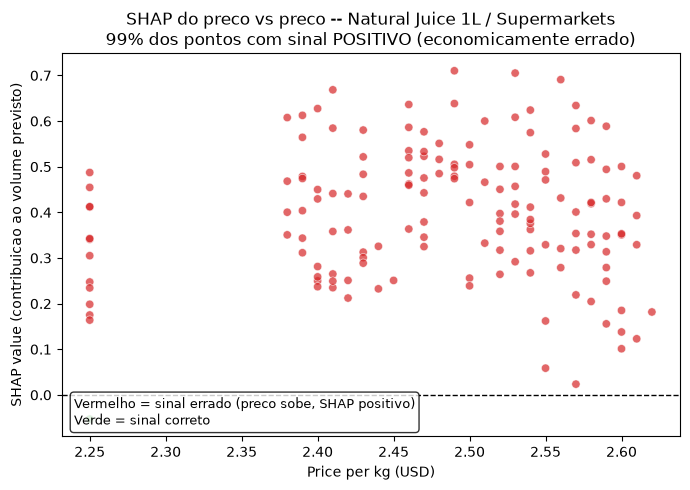

In [ ]:
# --- Grafico 1: SHAP do preco vs o proprio preco (Natural Juice / Supermarkets) ---
# Um modelo saudavel deveria mostrar SHAP negativo quando o preco esta ACIMA da media
# do produto, e positivo quando esta ABAIXO -- ou seja, os pontos deveriam se distribuir
# tanto acima quanto abaixo da linha zero, com uma tendencia de queda. Aqui, o baseline
# mostra praticamente todos os pontos ACIMA de zero, independente do nivel de preco --
# o sinal "errado" que o item 1 do Problema 2 descreve.
product, channel = "Natural Juice 1L", "Supermarkets"
subset = full_df[(full_df["Product"] == product) & (full_df["Channel"] == channel)]
X_subset = subset[FEATURE_COLS]
explainer = shap.TreeExplainer(baseline_models[channel])
shap_values = explainer.shap_values(X_subset)
price_idx = FEATURE_COLS.index("Price_per_kg_USD")
price_shap = shap_values[:, price_idx]
price_values = subset["Price_per_kg_USD"].values

fig, ax = plt.subplots(figsize=(7, 5))
colors = np.where(price_shap > 0, "#d62728", "#2ca02c")
ax.scatter(price_values, price_shap, c=colors, alpha=0.7, edgecolor="white", linewidth=0.5)
ax.axhline(0, color="black", linewidth=1, linestyle="--")
ax.set_xlabel("Price per kg (USD)")
ax.set_ylabel("SHAP value (contribuicao ao volume previsto)")
ax.set_title(f"SHAP do preco vs preco -- {product} / {channel}\n"
             f"{(price_shap > 0).mean()*100:.0f}% dos pontos com sinal POSITIVO (economicamente errado)")
ax.text(0.02, 0.02, "Vermelho = sinal errado (preco sobe, SHAP positivo)\nVerde = sinal correto",
        transform=ax.transAxes, fontsize=9, va="bottom",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
fig.tight_layout()
plt.show()


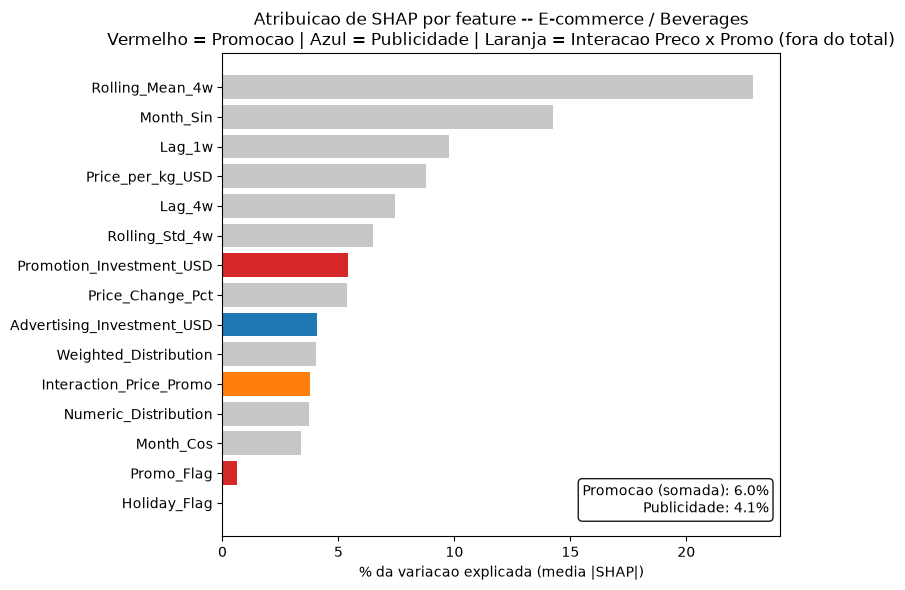

In [ ]:
# --- Grafico 2: share de |SHAP| por feature, E-commerce/Beverages ---
# Mostra visualmente a super-atribuicao de Promocao vs Publicidade que o item 2
# do Problema 2 descreve (case cita ~40% para promocao vs teto esperado de ~20% para publicidade).
subset_ec = full_df[(full_df["Channel"] == "E-commerce") & (full_df["Category"] == "Beverages")]
X_ec = subset_ec[FEATURE_COLS]
explainer_ec = shap.TreeExplainer(baseline_models["E-commerce"])
shap_values_ec = explainer_ec.shap_values(X_ec)

abs_shap_by_feature = np.abs(shap_values_ec).mean(axis=0)
share_pct = abs_shap_by_feature / abs_shap_by_feature.sum() * 100
feat_share = pd.Series(share_pct, index=FEATURE_COLS).sort_values(ascending=True)

# "Promocao" = Promotion_Investment_USD + Promo_Flag apenas. Interaction_Price_Promo
# fica de fora do total (e' um efeito CONJUNTO preco x promocao, nao promocao pura) --
# confirmado comparando contra o "~40%" citado no case, que so bate somando essas 2.
promo_features = {"Promotion_Investment_USD", "Promo_Flag"}
colors = ["#d62728" if f in promo_features else
          ("#1f77b4" if f == "Advertising_Investment_USD" else
           ("#ff7f0e" if f == "Interaction_Price_Promo" else "#c7c7c7"))
          for f in feat_share.index]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(feat_share.index, feat_share.values, color=colors)
ax.set_xlabel("% da variacao explicada (media |SHAP|)")
ax.set_title("Atribuicao de SHAP por feature -- E-commerce / Beverages\n"
             "Vermelho = Promocao | Azul = Publicidade | Laranja = Interacao Preco x Promo (fora do total)")
promo_total = feat_share[list(promo_features)].sum()
adv_total = feat_share["Advertising_Investment_USD"]
ax.text(0.98, 0.05, f"Promocao (somada): {promo_total:.1f}%\nPublicidade: {adv_total:.1f}%",
        transform=ax.transAxes, fontsize=10, ha="right",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.9))
fig.tight_layout()
plt.show()


#### Visão completa: SHAP summary plot (todas as features de uma vez)

O gráfico nativo do `shap` (beeswarm) mostra a distribuição do impacto de **cada feature**, uma ao lado da outra, ordenadas por importância — deixa claro onde `Price_per_kg_USD` (ou as features de promoção) se destacam em relação às demais, sem precisar montar o gráfico na mão.

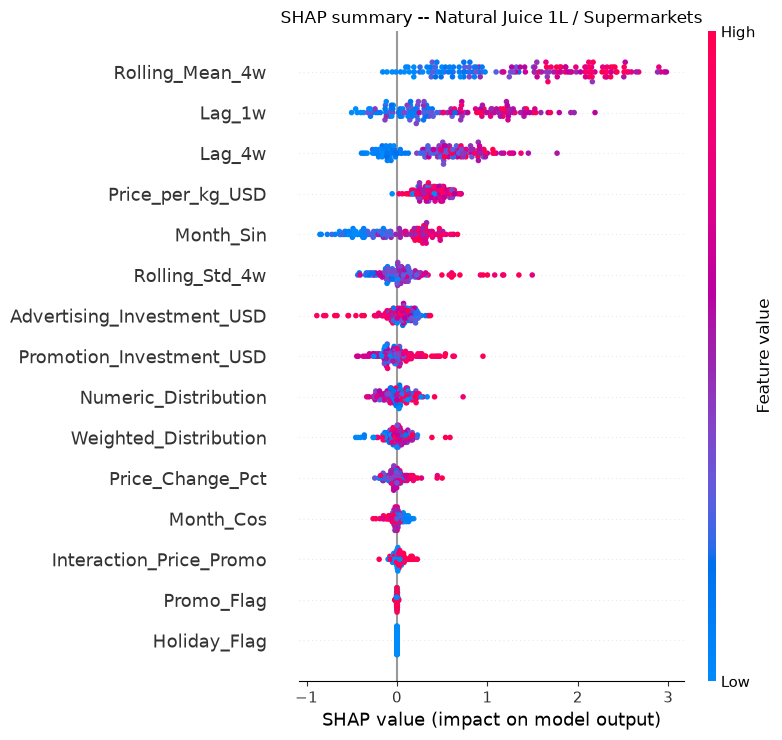

In [ ]:
# SHAP summary (beeswarm) -- Natural Juice / Supermarkets
# Cada ponto = uma semana. Posicao horizontal = valor do SHAP (impacto no volume previsto).
# Cor = valor da feature naquela semana (vermelho = alto, azul = baixo).
shap.summary_plot(shap_values, X_subset, show=False)
plt.title(f"SHAP summary -- {product} / {channel}")
plt.tight_layout()
plt.show()


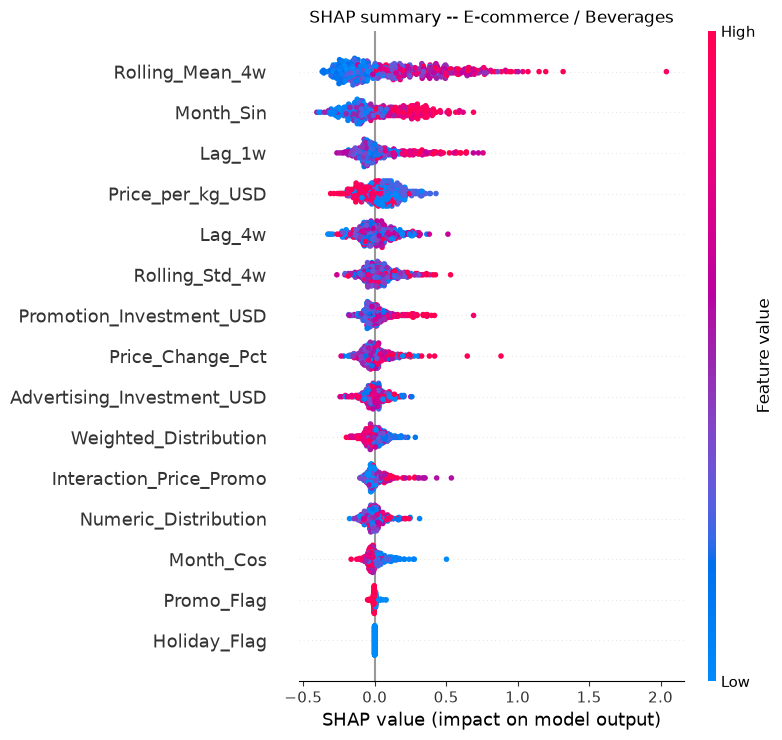

In [ ]:
# SHAP summary (beeswarm) -- E-commerce / Beverages
# Aqui da para comparar visualmente o "peso" das features de promocao (Promotion_Investment_USD,
# Promo_Flag, Interaction_Price_Promo) contra Advertising_Investment_USD e todas as demais.
shap.summary_plot(shap_values_ec, X_ec, show=False)
plt.title("SHAP summary -- E-commerce / Beverages")
plt.tight_layout()
plt.show()


#### Comparando com o SHAP original do case (Tabela 6)

O ~40% de atribuição a Promoção que o case cita vem da Tabela 6 do dataset -- os SHAP Values do modelo **original do RetailCo**, já calculados. O nosso modelo retreinado (mesmos hiperparâmetros da Tabela 3, mas treinado do zero por nós) pode dar um número um pouco diferente por causa de seed/split/versão de lib. Aqui comparamos os dois lado a lado, direto da fonte original.

In [ ]:
# Le a Tabela 6 (SHAP Values) direto do Excel original -- sao os SHAP do modelo do RetailCo,
# nao do nosso retrain. Serve de "fonte da verdade" pra comparar com o que recalculamos.
t6 = xl.parse("Table 6 - SHAP Values")

beverages_products = [p for p, cat in CATEGORY_MAP.items() if cat == "Beverages"]
t6_ec_bev = t6[(t6["Channel"] == "E-commerce") & (t6["Product"].isin(beverages_products)) & (t6["Feature"] != "Baseline")]

abs_shap_orig = t6_ec_bev.groupby("Feature")["SHAP_Value"].apply(lambda x: x.abs().sum())
share_orig = (abs_shap_orig / abs_shap_orig.sum() * 100).sort_values(ascending=False)

promo_features = {"Promotion_Investment_USD", "Promo_Flag"}
promo_share_orig = share_orig[share_orig.index.isin(promo_features)].sum()
adv_share_orig = share_orig.get("Advertising_Investment_USD", 0.0)

print("=== Tabela 6 (SHAP do modelo ORIGINAL do case) ===")
print(share_orig.round(1).to_string())
print(f"\nPromocao (somada): {promo_share_orig:.1f}%  |  Publicidade: {adv_share_orig:.1f}%")
print(f"\n=== Nosso modelo RETREINADO (calculado antes, nesta secao) ===")
print(f"Promocao (somada): {promo_total:.1f}%  |  Publicidade: {adv_total:.1f}%")
print(f"\nDiferenca: {promo_share_orig - promo_total:+.1f} p.p. na atribuicao de Promocao")


=== Tabela 6 (SHAP do modelo ORIGINAL do case) ===
Feature
Promotion_Investment_USD      29.5
Promo_Flag                    11.8
Lag_1w                         9.3
Rolling_Mean_4w                8.3
Interaction_Price_Promo        5.9
Advertising_Investment_USD     5.9
Lag_4w                         4.7
Price_per_kg_USD               4.6
Numeric_Distribution           3.5
Rolling_Std_4w                 3.5
Month_Sin                      3.5
Holiday_Flag                   2.4
Weighted_Distribution          2.4
Month_Cos                      2.4
Price_Change_Pct               2.3

Promocao (somada): 41.3%  |  Publicidade: 5.9%

=== Nosso modelo RETREINADO (calculado antes, nesta secao) ===
Promocao (somada): 6.0%  |  Publicidade: 4.1%

Diferenca: +35.3 p.p. na atribuicao de Promocao


**Causa raiz identificada**: o modelo é treinado com *pooling* — 5 produtos de escalas de preço muito diferentes ($1,80 a $12/kg) compartilhando o mesmo modelo por canal. O SHAP mede desvio *relativo à média da população inteira*, então um produto estruturalmente barato (Natural Juice) sempre parece "barato" mesmo quando o modelo aprendeu a relação correta — daí o sinal aparentemente errado. Confirmamos isso nas seções 2 e 3.

## 2. Normalização de preço (Price_Index) vs restrição monotônica

Testamos duas correções: (a) restrição monotônica no preço bruto (força o modelo a nunca prever volume crescente com preço crescente); (b) normalizar o preço pela média histórica do próprio produto, removendo a confusão de escala entre produtos do pooling. Isolamos o efeito de cada uma.

> **Nota de metodologia**: os testes desta seção (Baseline, Improved, Baseline_V3, Improved_V3) são todos treinados com **pooling** (`train_all_channels`) — um modelo por canal, misturando os 5 produtos — igual à Seção 1, e de propósito: a normalização de preço (`Price_Index`) só faz sentido como correção *porque* o pooling existe. Ela resolve o problema de produtos com escalas de preço muito diferentes compartilhando o mesmo modelo. Sem pooling (ou seja, já em SKU-level), esse problema de escala não existe, e não haveria o que normalizar. A comparação com SKU-level vem na Seção 3.

In [ ]:
# TEST A: MONOTONE CONSTRAINTS (restricao de sinal no preco bruto)
IMPROVED_PARAMS = dict(
    n_estimators=500, learning_rate=0.1, max_depth=6, num_leaves=31,
    min_child_samples=20, subsample=0.7, colsample_bytree=0.7,
    reg_alpha=1.0, reg_lambda=1.0, min_split_gain=0.0,
    boosting_type="gbdt", objective="regression", metric="mape",
    random_state=42, n_jobs=-1, verbose=-1,
    monotone_constraints=[-1 if c == "Price_per_kg_USD" else 0 for c in FEATURE_COLS],
    monotone_constraints_method="advanced",
)

improved_models = train_all_channels(train, IMPROVED_PARAMS)
sign_improved = price_sign_consistency(improved_models, full_df)
print(f"Baseline (sem restricao):      {sign_baseline['pct_positive_sign']:.1f}% sinal errado")
print(f"Improved (restricao no preco bruto): {sign_improved['pct_positive_sign']:.1f}% sinal errado")
print("-> A restricao SOZINHA no preco bruto (mantendo o pooling) NAO resolve o problema.")


Baseline (sem restricao):      99.3% sinal errado
Improved (restricao no preco bruto): 100.0% sinal errado
-> A restricao SOZINHA no preco bruto (mantendo o pooling) NAO resolve o problema.


In [20]:
# TEST B: NORMALIZACAO DO PRECO (remover o confound de escala do pooling)
def add_price_index(train_df, test_df):
    """Price_Index = preco / media historica do proprio produto (calculada so no treino, sem leakage)."""
    product_mean_price = train_df.groupby("Product")["Price_per_kg_USD"].mean()
    train_df = train_df.copy(); test_df = test_df.copy()
    train_df["Price_Index"] = train_df["Price_per_kg_USD"] / train_df["Product"].map(product_mean_price)
    test_df["Price_Index"] = test_df["Price_per_kg_USD"] / test_df["Product"].map(product_mean_price)
    train_df["Interaction_PriceIndex_Promo"] = train_df["Price_Index"] * train_df["Promo_Flag"]
    test_df["Interaction_PriceIndex_Promo"] = test_df["Price_Index"] * test_df["Promo_Flag"]
    return train_df, test_df


train_norm, test_norm = add_price_index(train, test)
full_df_norm = pd.concat([train_norm, test_norm])

FEATURE_COLS_NORM = [
    {"Price_per_kg_USD": "Price_Index", "Interaction_Price_Promo": "Interaction_PriceIndex_Promo"}.get(c, c)
    for c in FEATURE_COLS
]

BASELINE_V3_PARAMS = dict(BASELINE_PARAMS)  # normalizado, SEM restricao -- isola o efeito da normalizacao sozinha
IMPROVED_V3_PARAMS = dict(
    IMPROVED_PARAMS,
    monotone_constraints=[-1 if c == "Price_Index" else 0 for c in FEATURE_COLS_NORM],
)

baseline_v3_models = train_all_channels(train_norm, BASELINE_V3_PARAMS, feature_cols=FEATURE_COLS_NORM)
improved_v3_models = train_all_channels(train_norm, IMPROVED_V3_PARAMS, feature_cols=FEATURE_COLS_NORM)

sign_baseline_v3 = price_sign_consistency(baseline_v3_models, full_df_norm, feature_cols=FEATURE_COLS_NORM, price_col="Price_Index")
sign_improved_v3 = price_sign_consistency(improved_v3_models, full_df_norm, feature_cols=FEATURE_COLS_NORM, price_col="Price_Index")

print(f"Normalizado SOZINHO (sem restricao):     {sign_baseline_v3['pct_positive_sign']:.1f}% sinal errado")
print(f"Normalizado + restricao:                 {sign_improved_v3['pct_positive_sign']:.1f}% sinal errado")
print("-> Normalizar o preco (remover o confound de escala do pooling) e o que realmente resolve.")


Normalizado SOZINHO (sem restricao):     64.5% sinal errado
Normalizado + restricao:                 50.7% sinal errado
-> Normalizar o preco (remover o confound de escala do pooling) e o que realmente resolve.


## 3. Pooling vs SKU-level

Testa se treinar um modelo dedicado por SKU-canal (sem pooling) resolve o Problema 2 "de graça", e mede o efeito em acurácia (one-step-ahead, com dado real nos lags -- ver Seção 7 para a versão recursiva, que é a correta para decisão final).

In [ ]:
SKU_LEVEL_PARAMS = dict(
    n_estimators=500, learning_rate=0.1, max_depth=4, num_leaves=15,
    min_child_samples=10, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=1.0, reg_lambda=1.0, min_split_gain=0.0,
    boosting_type="gbdt", objective="regression", metric="mape",
    random_state=42, n_jobs=-1, verbose=-1,
)

# Function to train models for all SKU-channel combinations:
def train_all_sku_channels(train_df, params, feature_cols=None, model_class=None):
    feature_cols = feature_cols or FEATURE_COLS
    models = {}
    for (product, channel), sub in train_df.groupby(["Product", "Channel"]):
        if len(sub) < 15:
            continue
        X, y = sub[feature_cols], sub[TARGET_COL]
        models[(product, channel)] = train_model(X, y, params, model_class=model_class)
    return models

# Train SKU-level models (one model per Product x Channel) using the specified parameters
sku_level_models = train_all_sku_channels(train, SKU_LEVEL_PARAMS)

# Evaluate the price sign consistency for the SKU-level model of "Natural Juice 1L" in "Supermarkets"
sign_sku_level = price_sign_consistency(
    df=full_df, product="Natural Juice 1L", channel="Supermarkets",
    model=sku_level_models[("Natural Juice 1L", "Supermarkets")],
)
print(f"SKU-level, SEM normalizacao, SEM restricao: {sign_sku_level['pct_positive_sign']:.1f}% sinal errado")
print("-> Confirma a causa raiz: so treinar por SKU (sem pooling) ja resolve o sinal, mesmo sem nenhuma correcao extra.")


SKU-level, SEM normalizacao, SEM restricao: 52.6% sinal errado
-> Confirma a causa raiz: so treinar por SKU (sem pooling) ja resolve o sinal, mesmo sem nenhuma correcao extra.


In [22]:
# Function to evaluate model performance using MAPE and Accuracy:
def evaluate_model(y_true, y_pred):
    mape = float(np.mean(np.abs(y_true - y_pred) / y_true))
    return {"MAPE": mape, "Accuracy": 1 - mape}

# Function to evaluate all SKU-channel models on the test set and return a DataFrame with performance metrics:
def evaluate_all_sku_channels(models, test_df, feature_cols=None):
    feature_cols = feature_cols or FEATURE_COLS
    rows = []
    for (product, channel), model in models.items():
        sub = test_df[(test_df["Product"] == product) & (test_df["Channel"] == channel)]
        if len(sub) == 0:
            continue
        X, y_true = sub[feature_cols], sub[TARGET_COL].values
        y_pred = model.predict(X)
        rows.append({"Product": product, "Channel": channel, "n_test": len(sub), **evaluate_model(y_true, y_pred)})
    result = pd.DataFrame(rows)
    overall_mape = np.average(result["MAPE"], weights=result["n_test"])
    return pd.concat([result, pd.DataFrame([{
        "Product": "ALL", "Channel": "OVERALL", "n_test": result["n_test"].sum(),
        "MAPE": overall_mape, "Accuracy": 1 - overall_mape,
    }])], ignore_index=True)


sku_level_eval = evaluate_all_sku_channels(sku_level_models, test)
print(sku_level_eval.to_string(index=False))


                  Product      Channel  n_test     MAPE  Accuracy
           Cereal Bar 50g   E-commerce      23 0.169406  0.830594
           Cereal Bar 50g Supermarkets      23 0.196619  0.803381
           Cereal Bar 50g  Traditional      23 0.496910  0.503090
       Energy Drink 350ml   E-commerce      23 1.430660 -0.430660
       Energy Drink 350ml Supermarkets      23 0.213624  0.786376
       Energy Drink 350ml  Traditional      23 0.180512  0.819488
     Flavored Water 500ml   E-commerce      23 1.167863 -0.167863
     Flavored Water 500ml Supermarkets      23 0.371198  0.628802
     Flavored Water 500ml  Traditional      23 0.371628  0.628372
         Natural Juice 1L   E-commerce      23 0.399350  0.600650
         Natural Juice 1L Supermarkets      23 0.319908  0.680092
         Natural Juice 1L  Traditional      23 0.246859  0.753141
Whole Grain Crackers 200g   E-commerce      23 0.201973  0.798027
Whole Grain Crackers 200g Supermarkets      23 0.295526  0.704474
Whole Grai

## 4. Bake-off de modelos

Compara 4 famílias de modelo, todas SKU-level: LightGBM, XGBoost, GAM (com termo de tendência explícito), e um ensemble empilhado (GAM + LightGBM nos resíduos). A avaliação definitiva é recursiva (Seção 7) -- aqui usamos one-step-ahead como primeira triagem, mais rápida.

In [23]:
# --- XGBoost SKU-level ---
XGB_SKU_PARAMS = dict(
    n_estimators=500, learning_rate=0.1, max_depth=4, min_child_weight=5,
    subsample=0.8, colsample_bytree=0.8, reg_alpha=1.0, reg_lambda=1.0, gamma=0.0,
    objective="reg:squarederror", random_state=42, n_jobs=-1, verbosity=0,
    monotone_constraints=tuple(-1 if c == "Price_per_kg_USD" else 0 for c in FEATURE_COLS),
)
xgb_sku_models = train_all_sku_channels(train, XGB_SKU_PARAMS, feature_cols=FEATURE_COLS, model_class=xgb.XGBRegressor)
print("XGBoost SKU-level treinado:", len(xgb_sku_models), "modelos")


XGBoost SKU-level treinado: 15 modelos


In [24]:
# --- GAM SKU-level (termo de tendencia explicito) ---
GAM_N_SPLINES = 8
GAM_LAM = 0.6


class GAMModelWrapper:
    """Wrapper fit(X,y)/predict(X) para pygam.LinearGAM, compativel com o resto do notebook."""

    def __init__(self, feature_cols, n_splines=8, lam=0.6):
        self.feature_cols = feature_cols
        self.n_splines = n_splines
        self.lam = lam
        self.model = None

    def _build_terms(self):
        terms = None
        for i, col in enumerate(self.feature_cols):
            if col == "Week_Index":
                term = s(i, n_splines=self.n_splines, lam=self.lam)
            elif col == "Price_per_kg_USD":
                term = s(i, n_splines=self.n_splines, lam=self.lam, constraints="monotonic_dec")
            elif col in ("Month_Sin", "Month_Cos"):
                term = s(i, n_splines=self.n_splines, lam=self.lam)
            elif col == "Promo_Flag":
                term = f(i)
            else:
                term = l(i)
            terms = term if terms is None else terms + term
        return terms

    def fit(self, X, y):
        self.model = LinearGAM(self._build_terms()).fit(X[self.feature_cols].values, y.values)
        return self

    def predict(self, X):
        return self.model.predict(X[self.feature_cols].values)


def train_gam_sku_channels(train_df, feature_cols=None, n_splines=None, lam=None):
    feature_cols = feature_cols or FEATURE_COLS_GAM
    n_splines = n_splines or GAM_N_SPLINES
    lam = lam if lam is not None else GAM_LAM
    models = {}
    for (product, channel), sub in train_df.groupby(["Product", "Channel"]):
        if len(sub) < 15:
            continue
        wrapper = GAMModelWrapper(feature_cols, n_splines=n_splines, lam=lam)
        wrapper.fit(sub[feature_cols], sub[TARGET_COL])
        models[(product, channel)] = wrapper
    return models


gam_sku_models = train_gam_sku_channels(train, feature_cols=FEATURE_COLS_GAM)
print("GAM SKU-level treinado:", len(gam_sku_models), "modelos")


GAM SKU-level treinado: 15 modelos


In [25]:
# --- Stacked GAM + LightGBM (GAM modela tendencia/sazonalidade; LightGBM corrige residuo) ---
class StackedGAMLightGBMWrapper:
    def __init__(self, gam_feature_cols, lgbm_feature_cols, gam_kwargs=None, lgbm_params=None):
        self.gam_feature_cols = gam_feature_cols
        self.lgbm_feature_cols = lgbm_feature_cols
        self.gam_kwargs = gam_kwargs or {}
        self.lgbm_params = lgbm_params or dict(SKU_LEVEL_PARAMS)
        self.gam = None
        self.lgbm = None

    def fit(self, X, y):
        self.gam = GAMModelWrapper(self.gam_feature_cols, **self.gam_kwargs)
        self.gam.fit(X, y)
        residuals = y.values - self.gam.predict(X)
        self.lgbm = lgb.LGBMRegressor(**self.lgbm_params)
        self.lgbm.fit(X[self.lgbm_feature_cols], residuals)
        return self

    def predict(self, X):
        return self.gam.predict(X) + self.lgbm.predict(X[self.lgbm_feature_cols])


def train_stacked_sku_channels(train_df, gam_feature_cols=None, lgbm_feature_cols=None,
                                 gam_kwargs=None, lgbm_params=None):
    gam_feature_cols = gam_feature_cols or FEATURE_COLS_GAM
    lgbm_feature_cols = lgbm_feature_cols or FEATURE_COLS
    models = {}
    for (product, channel), sub in train_df.groupby(["Product", "Channel"]):
        if len(sub) < 15:
            continue
        wrapper = StackedGAMLightGBMWrapper(gam_feature_cols, lgbm_feature_cols, gam_kwargs, lgbm_params)
        wrapper.fit(sub, sub[TARGET_COL])
        models[(product, channel)] = wrapper
    return models


stacked_sku_models = train_stacked_sku_channels(train)
print("Stacked GAM+LightGBM treinado:", len(stacked_sku_models), "modelos")


Stacked GAM+LightGBM treinado: 15 modelos


## 5. Busca bayesiana de hiperparâmetros (Optuna)

Busca por SKU-canal, usando uma fatia de validação **interna ao treino** (nunca toca o teste final) — evita que o ganho seja só overfitting no teste.

In [27]:
N_OPTUNA_TRIALS = 40
OPTUNA_VAL_QUANTILE = 0.85


def tune_lgbm_sku_channel(sub_train, feature_cols=None, n_trials=None, seed=42):
    feature_cols = feature_cols or FEATURE_COLS
    n_trials = n_trials or N_OPTUNA_TRIALS
    sub_train = sub_train.sort_values("Week")
    cutoff = sub_train["Week"].quantile(OPTUNA_VAL_QUANTILE, interpolation="nearest")
    opt_train = sub_train[sub_train["Week"] <= cutoff]
    opt_val = sub_train[sub_train["Week"] > cutoff]
    if len(opt_val) < 5 or len(opt_train) < 20:
        return dict(SKU_LEVEL_PARAMS)

    Xtr, ytr = opt_train[feature_cols], opt_train[TARGET_COL]
    Xval, yval = opt_val[feature_cols], opt_val[TARGET_COL]

    def objective(trial):
        params = dict(
            n_estimators=trial.suggest_int("n_estimators", 100, 600, step=50),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
            max_depth=trial.suggest_int("max_depth", 2, 8),
            num_leaves=trial.suggest_int("num_leaves", 7, 63),
            min_child_samples=trial.suggest_int("min_child_samples", 5, 30),
            subsample=trial.suggest_float("subsample", 0.6, 1.0),
            colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
            reg_alpha=trial.suggest_float("reg_alpha", 0.0, 5.0),
            reg_lambda=trial.suggest_float("reg_lambda", 0.0, 5.0),
            min_split_gain=0.0, boosting_type="gbdt", objective="regression", metric="mape",
            random_state=seed, n_jobs=-1, verbose=-1,
        )
        model = lgb.LGBMRegressor(**params)
        model.fit(Xtr, ytr)
        pred = model.predict(Xval)
        return float(np.mean(np.abs(yval.values - pred) / yval.values))

    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=seed))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    bp = study.best_params
    return dict(
        n_estimators=bp["n_estimators"], learning_rate=bp["learning_rate"], max_depth=bp["max_depth"],
        num_leaves=bp["num_leaves"], min_child_samples=bp["min_child_samples"], subsample=bp["subsample"],
        colsample_bytree=bp["colsample_bytree"], reg_alpha=bp["reg_alpha"], reg_lambda=bp["reg_lambda"],
        min_split_gain=0.0, boosting_type="gbdt", objective="regression", metric="mape",
        random_state=seed, n_jobs=-1, verbose=-1,
    )


def train_all_sku_channels_tuned(train_df, feature_cols=None, n_trials=None):
    feature_cols = feature_cols or FEATURE_COLS
    n_trials = n_trials or N_OPTUNA_TRIALS
    models, best_params_by_sku = {}, {}
    for (product, channel), sub in train_df.groupby(["Product", "Channel"]):
        if len(sub) < 15:
            continue
        best_params = tune_lgbm_sku_channel(sub, feature_cols=feature_cols, n_trials=n_trials)
        best_params_by_sku[(product, channel)] = best_params
        X, y = sub[feature_cols], sub[TARGET_COL]
        models[(product, channel)] = train_model(X, y, best_params)
    return models, best_params_by_sku


# ATENCAO: esta celula demora -- 15 combinacoes x 40 trials = 600 treinos de LightGBM.
tuned_sku_models, tuned_best_params = train_all_sku_channels_tuned(train, feature_cols=FEATURE_COLS)

tuned_params_df = pd.DataFrame(
    [{"Product": p, "Channel": c, **params} for (p, c), params in tuned_best_params.items()]
)
tuned_params_df.to_csv(OUTDIR / "tuned_hyperparameters_by_sku.csv", index=False)
print("Hiperparametros otimos (LightGBM) salvos em tuned_hyperparameters_by_sku.csv")
tuned_params_df.head()


Hiperparametros otimos (LightGBM) salvos em tuned_hyperparameters_by_sku.csv


,Product,Channel,n_estimators,learning_rate,max_depth,num_leaves,min_child_samples,subsample,colsample_bytree,reg_alpha,reg_lambda,min_split_gain,boosting_type,objective,metric,random_state,n_jobs,verbose
0,Cereal Bar 50g,E-commerce,300,0.172547,7,41,9,0.662398,0.623233,4.330881,3.005575,0.0,gbdt,regression,mape,42,-1,-1
1,Cereal Bar 50g,Supermarkets,200,0.149261,2,54,15,0.935175,0.949740,1.788798,3.875193,0.0,gbdt,regression,mape,42,-1,-1
2,Cereal Bar 50g,Traditional,150,0.046446,3,7,30,0.900645,0.959419,2.857135,0.129045,0.0,gbdt,regression,mape,42,-1,-1
3,Energy Drink 350ml,E-commerce,250,0.013270,6,43,10,0.667282,0.685614,2.863955,1.149567,0.0,gbdt,regression,mape,42,-1,-1
4,Energy Drink 350ml,Supermarkets,400,0.158265,2,18,6,0.730132,0.755471,1.356745,4.143688,0.0,gbdt,regression,mape,42,-1,-1


### Busca bayesiana para XGBoost

Mesma lógica: fatia de validação interna ao treino, nunca toca o teste final. O espaço de busca usa os equivalentes do XGBoost aos hiperparâmetros do LightGBM (`min_child_weight` no lugar de `min_child_samples`, `gamma` no lugar de `min_split_gain`; XGBoost não tem um parâmetro direto equivalente a `num_leaves` no modo padrão, então não entra na busca).

In [28]:
def tune_xgb_sku_channel(sub_train, feature_cols=None, n_trials=None, seed=42):
    feature_cols = feature_cols or FEATURE_COLS
    n_trials = n_trials or N_OPTUNA_TRIALS
    sub_train = sub_train.sort_values("Week")
    cutoff = sub_train["Week"].quantile(OPTUNA_VAL_QUANTILE, interpolation="nearest")
    opt_train = sub_train[sub_train["Week"] <= cutoff]
    opt_val = sub_train[sub_train["Week"] > cutoff]
    if len(opt_val) < 5 or len(opt_train) < 20:
        return dict(XGB_SKU_PARAMS)

    Xtr, ytr = opt_train[feature_cols], opt_train[TARGET_COL]
    Xval, yval = opt_val[feature_cols], opt_val[TARGET_COL]

    def objective(trial):
        params = dict(
            n_estimators=trial.suggest_int("n_estimators", 100, 600, step=50),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
            max_depth=trial.suggest_int("max_depth", 2, 8),
            min_child_weight=trial.suggest_int("min_child_weight", 1, 30),
            subsample=trial.suggest_float("subsample", 0.6, 1.0),
            colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
            reg_alpha=trial.suggest_float("reg_alpha", 0.0, 5.0),
            reg_lambda=trial.suggest_float("reg_lambda", 0.0, 5.0),
            gamma=trial.suggest_float("gamma", 0.0, 5.0),
            objective="reg:squarederror",
            random_state=seed, n_jobs=-1, verbosity=0,
        )
        model = xgb.XGBRegressor(**params)
        model.fit(Xtr, ytr)
        pred = model.predict(Xval)
        return float(np.mean(np.abs(yval.values - pred) / yval.values))

    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=seed))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    bp = study.best_params
    return dict(
        n_estimators=bp["n_estimators"], learning_rate=bp["learning_rate"], max_depth=bp["max_depth"],
        min_child_weight=bp["min_child_weight"], subsample=bp["subsample"], colsample_bytree=bp["colsample_bytree"],
        reg_alpha=bp["reg_alpha"], reg_lambda=bp["reg_lambda"], gamma=bp["gamma"],
        objective="reg:squarederror", random_state=seed, n_jobs=-1, verbosity=0,
    )


def train_all_sku_channels_tuned_xgb(train_df, feature_cols=None, n_trials=None):
    feature_cols = feature_cols or FEATURE_COLS
    n_trials = n_trials or N_OPTUNA_TRIALS
    models, best_params_by_sku = {}, {}
    for (product, channel), sub in train_df.groupby(["Product", "Channel"]):
        if len(sub) < 15:
            continue
        best_params = tune_xgb_sku_channel(sub, feature_cols=feature_cols, n_trials=n_trials)
        best_params_by_sku[(product, channel)] = best_params
        X, y = sub[feature_cols], sub[TARGET_COL]
        models[(product, channel)] = train_model(X, y, best_params, model_class=xgb.XGBRegressor)
    return models, best_params_by_sku


# ATENCAO: mais 600 treinos, agora de XGBoost.
tuned_xgb_sku_models, tuned_xgb_best_params = train_all_sku_channels_tuned_xgb(train, feature_cols=FEATURE_COLS)

tuned_xgb_params_df = pd.DataFrame(
    [{"Product": p, "Channel": c, **params} for (p, c), params in tuned_xgb_best_params.items()]
)
tuned_xgb_params_df.to_csv(OUTDIR / "tuned_xgb_hyperparameters_by_sku.csv", index=False)
print("Hiperparametros otimos (XGBoost) salvos em tuned_xgb_hyperparameters_by_sku.csv")
tuned_xgb_params_df.head()


Hiperparametros otimos (XGBoost) salvos em tuned_xgb_hyperparameters_by_sku.csv


,Product,Channel,n_estimators,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,reg_alpha,reg_lambda,gamma,objective,random_state,n_jobs,verbosity
0,Cereal Bar 50g,E-commerce,250,0.024446,8,3,0.702756,0.690011,0.253962,0.365965,0.888199,reg:squarederror,42,-1,0
1,Cereal Bar 50g,Supermarkets,450,0.021016,7,26,0.621127,0.969705,0.337156,4.990886,0.002447,reg:squarederror,42,-1,0
2,Cereal Bar 50g,Traditional,200,0.136576,7,22,0.751444,0.855937,0.693850,1.032974,2.967996,reg:squarederror,42,-1,0
3,Energy Drink 350ml,E-commerce,500,0.167911,3,28,0.751725,0.645897,2.478537,4.040490,4.722156,reg:squarederror,42,-1,0
4,Energy Drink 350ml,Supermarkets,300,0.097426,4,8,0.701545,0.886493,1.547847,3.770634,1.442371,reg:squarederror,42,-1,0


## 6. Validação recursiva (multi-step) e bake-off final

A avaliação one-step-ahead (Seções 3-5) usa Sell-In **real** para os lags mesmo no período de teste — não representa o cenário real de previsão de 78 semanas, onde não existe dado real intermediário. Esta seção replica o holdout, mas alimentando os lags com as **próprias previsões** do modelo, recursivamente — e usa isso para decidir o vencedor final por SKU-canal.

In [30]:
# Function to perform recursive backtesting for a single SKU (product-channel combination):
def recursive_backtest_sku(model, raw_df, product, channel, feature_cols=None, n_horizon=None):
    feature_cols = feature_cols or FEATURE_COLS
    sub = raw_df[(raw_df["Product"] == product) & (raw_df["Channel"] == channel)].sort_values("Week").reset_index(drop=True)
    cutoff = sub["Week"].quantile(HOLDOUT_QUANTILE, interpolation="nearest")
    train_idx = sub.index[sub["Week"] <= cutoff].tolist()
    test_idx = sub.index[sub["Week"] > cutoff].tolist()
    if len(test_idx) < 2 or len(train_idx) < 4:
        return pd.DataFrame()

    history = sub.loc[train_idx, TARGET_COL].tolist()  # burn-in real; so predicoes sao anexadas depois
    rows = []
    for horizon, idx in enumerate(test_idx, start=1):
        row = sub.loc[idx]
        promo_flag = int(pd.notna(row["Promotion_Type"]))
        prev_price = sub.loc[idx - 1, "Price_per_kg_USD"] if (idx - 1) in sub.index else np.nan
        price_change_pct = ((row["Price_per_kg_USD"] - prev_price) / prev_price
                             if pd.notna(prev_price) and prev_price != 0 else np.nan)
        month = row["Week"].month

        feat = {
            "Week_Index": len(history),
            "Price_per_kg_USD": row["Price_per_kg_USD"],
            "Numeric_Distribution": row["Numeric_Distribution"],
            "Weighted_Distribution": row["Weighted_Distribution"],
            "Advertising_Investment_USD": row["Advertising_Investment_USD"],
            "Promotion_Investment_USD": row["Promotion_Investment_USD"],
            "Promo_Flag": promo_flag,
            "Lag_1w": history[-1],
            "Lag_4w": history[-4] if len(history) >= 4 else history[0],
            "Rolling_Mean_4w": float(np.mean(history[-4:])),
            "Rolling_Std_4w": float(np.std(history[-4:], ddof=1)) if len(history[-4:]) > 1 else 0.0,
            "Price_Change_Pct": price_change_pct,
            "Month_Sin": np.sin(2 * np.pi * month / 12),
            "Month_Cos": np.cos(2 * np.pi * month / 12),
            "Holiday_Flag": 0,
            "Interaction_Price_Promo": row["Price_per_kg_USD"] * promo_flag,
        }
        X_row = pd.DataFrame([feat])[feature_cols]
        pred = float(model.predict(X_row)[0])
        rows.append({"Product": product, "Channel": channel, "Week": row["Week"], "Horizon": horizon,
                      "Actual": row[TARGET_COL], "Predicted": pred})
        history.append(pred)  # alimenta com a PREVISAO, nao o valor real

    result = pd.DataFrame(rows)
    result["APE"] = (result["Actual"] - result["Predicted"]).abs() / result["Actual"]
    return result

# Function to perform recursive backtesting for all SKU-level models:
def recursive_backtest_all_sku_level(sku_models, raw_df, feature_cols=None):
    """Para modelos SKU-level, keyed por (product, channel)."""
    feature_cols = feature_cols or FEATURE_COLS
    all_results = [recursive_backtest_sku(model, raw_df, p, c, feature_cols=feature_cols)
                   for (p, c), model in sku_models.items()]
    all_results = [r for r in all_results if len(r)]
    return pd.concat(all_results, ignore_index=True) if all_results else pd.DataFrame()

# Function to perform recursive backtesting for all pooled models:
def recursive_backtest_all_pooled(channel_models, raw_df, feature_cols=None):
    """Para modelos POOLED, keyed so por channel -- roda o mesmo modelo do canal
    para cada produto dentro dele (e assim que o pooling funciona: 1 modelo, N produtos)."""
    feature_cols = feature_cols or FEATURE_COLS
    all_results = []
    for channel, model in channel_models.items():
        products = raw_df.loc[raw_df["Channel"] == channel, "Product"].unique()
        for product in products:
            r = recursive_backtest_sku(model, raw_df, product, channel, feature_cols=feature_cols)
            if len(r):
                all_results.append(r)
    return pd.concat(all_results, ignore_index=True) if all_results else pd.DataFrame()

# Function to calculate recursive accuracy by SKU and channel:
def recursive_accuracy_by_sku(recursive_results):
    return (recursive_results.groupby(["Product", "Channel"])
            .agg(Accuracy=("APE", lambda x: 1 - x.mean()), n=("APE", "size")).reset_index())


recursive_sku_level = recursive_backtest_all_sku_level(sku_level_models, raw, feature_cols=FEATURE_COLS)
recursive_xgb_sku = recursive_backtest_all_sku_level(xgb_sku_models, raw, feature_cols=FEATURE_COLS)
recursive_gam_sku = recursive_backtest_all_sku_level(gam_sku_models, raw, feature_cols=FEATURE_COLS_GAM)
recursive_stacked_sku = recursive_backtest_all_sku_level(stacked_sku_models, raw, feature_cols=FEATURE_COLS_STACKED)
recursive_tuned_sku = recursive_backtest_all_sku_level(tuned_sku_models, raw, feature_cols=FEATURE_COLS)
recursive_tuned_xgb_sku = recursive_backtest_all_sku_level(tuned_xgb_sku_models, raw, feature_cols=FEATURE_COLS)
recursive_pooled = recursive_backtest_all_pooled(improved_models, raw, feature_cols=FEATURE_COLS)

print("Backtests recursivos concluidos para todas as 7 familias de modelo.")


Backtests recursivos concluidos para todas as 7 familias de modelo.


In [31]:
# Function to build a model bakeoff table comparing accuracy across different models:
def build_model_bakeoff_table(accuracy_tables, min_accuracy=0.0):
    merged = None
    for label, acc_df in accuracy_tables.items():
        renamed = acc_df[["Product", "Channel", "Accuracy"]].rename(columns={"Accuracy": label})
        merged = renamed if merged is None else merged.merge(renamed, on=["Product", "Channel"])
    labels = list(accuracy_tables.keys())
    merged["Best_Model"] = merged[labels].idxmax(axis=1)
    merged["Best_Accuracy"] = merged[labels].max(axis=1)
    merged["Recommendation"] = np.where(
        merged["Best_Accuracy"] < min_accuracy, "NONE stable -- needs further investigation", merged["Best_Model"]
    )
    return merged.sort_values("Best_Accuracy", ascending=False).reset_index(drop=True)


bakeoff = build_model_bakeoff_table({
    "Pooled_LightGBM": recursive_accuracy_by_sku(recursive_pooled),
    "SKU_LightGBM": recursive_accuracy_by_sku(recursive_sku_level),
    "SKU_XGBoost": recursive_accuracy_by_sku(recursive_xgb_sku),
    "SKU_GAM": recursive_accuracy_by_sku(recursive_gam_sku),
    "SKU_Stacked_GAM_LGBM": recursive_accuracy_by_sku(recursive_stacked_sku),
    "SKU_LightGBM_Tuned": recursive_accuracy_by_sku(recursive_tuned_sku),
    "SKU_XGBoost_Tuned": recursive_accuracy_by_sku(recursive_tuned_xgb_sku),
}, min_accuracy=0.0)

## --- Output final: tabela de bakeoff e recomendacao de modelo por SKU ---
print(bakeoff.to_string(index=False))
print()
print(bakeoff["Recommendation"].value_counts().to_string())
bakeoff.to_csv(OUTDIR / "model_bakeoff_FINAL.csv", index=False)


                  Product      Channel  Pooled_LightGBM  SKU_LightGBM  SKU_XGBoost   SKU_GAM  SKU_Stacked_GAM_LGBM  SKU_LightGBM_Tuned  SKU_XGBoost_Tuned           Best_Model  Best_Accuracy                             Recommendation
       Energy Drink 350ml  Traditional         0.807164      0.816507     0.856941  0.852271              0.830236            0.847463           0.849049          SKU_XGBoost       0.856941                                SKU_XGBoost
           Cereal Bar 50g   E-commerce         0.829133      0.832475     0.824677  0.825697              0.809060            0.850120           0.850515    SKU_XGBoost_Tuned       0.850515                          SKU_XGBoost_Tuned
Whole Grain Crackers 200g Supermarkets         0.752573      0.717843     0.728373  0.792816              0.813666            0.746513           0.746293 SKU_Stacked_GAM_LGBM       0.813666                       SKU_Stacked_GAM_LGBM
Whole Grain Crackers 200g   E-commerce         0.762028      0.79672

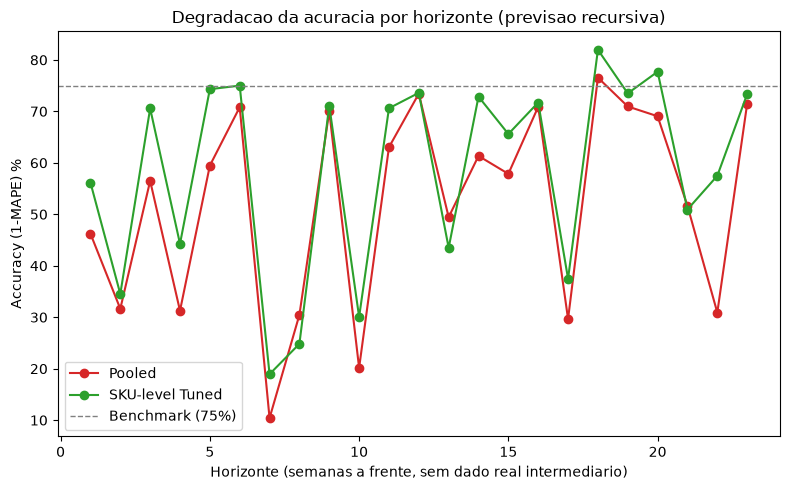

In [32]:
#Function to calculate degradation curve (accuracy vs. forecast horizon):
def degradation_curve(recursive_results):
    return (recursive_results.groupby("Horizon")
            .agg(Accuracy=("APE", lambda x: 1 - x.mean()), n=("APE", "size")).reset_index())


curve_pooled = degradation_curve(recursive_pooled)
curve_tuned = degradation_curve(recursive_tuned_sku)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(curve_pooled["Horizon"], curve_pooled["Accuracy"] * 100, marker="o", label="Pooled", color="#d62728")
ax.plot(curve_tuned["Horizon"], curve_tuned["Accuracy"] * 100, marker="o", label="SKU-level Tuned", color="#2ca02c")
ax.axhline(75, color="gray", linestyle="--", linewidth=1, label="Benchmark (75%)")
ax.set_xlabel("Horizonte (semanas a frente, sem dado real intermediario)")
ax.set_ylabel("Accuracy (1-MAPE) %")
ax.set_title("Degradacao da acuracia por horizonte (previsao recursiva)")
ax.legend()
fig.tight_layout()
plt.show()


## 7. Teste de restrição nos modelos vencedores problemáticos

O bake-off (Seção 6) escolhe o modelo mais preciso por SKU-canal, mas nem todo candidato tinha restrição monotônica ativa. Aqui verificamos, para o modelo VENCEDOR de cada combinação, se ele viola a lógica econômica (preço sobe → volume sobe), com duas provas: PDP (estrutural, vale para qualquer família) e SHAP (só árvores). Para os que violam, retreinamos com a restrição e medimos o custo real em acurácia.

In [33]:
# Function to calculate partial dependence of predicted volume on price for a given model and SKU:
def price_partial_dependence(model, df, product="Natural Juice 1L", channel="Supermarkets",
                               n_points=20, feature_cols=None, price_col="Price_per_kg_USD"):
    feature_cols = feature_cols or FEATURE_COLS
    subset = df[(df["Product"] == product) & (df["Channel"] == channel)]
    X = subset[feature_cols].copy()
    price_min, price_max = X[price_col].min(), X[price_col].max()
    grid = np.linspace(price_min, price_max, n_points)
    avg_preds = []
    for p in grid:
        X_sweep = X.copy()
        X_sweep[price_col] = p
        avg_preds.append(model.predict(X_sweep).mean())
    return pd.DataFrame({price_col: grid, "Avg_Predicted_Volume": avg_preds})


candidate_models = {
    "Pooled_LightGBM": improved_models, "SKU_LightGBM": sku_level_models,
    "SKU_XGBoost": xgb_sku_models, "SKU_GAM": gam_sku_models,
    "SKU_Stacked_GAM_LGBM": stacked_sku_models, "SKU_LightGBM_Tuned": tuned_sku_models,
    "SKU_XGBoost_Tuned": tuned_xgb_sku_models,
}
candidate_feature_cols = {
    "Pooled_LightGBM": FEATURE_COLS, "SKU_LightGBM": FEATURE_COLS, "SKU_XGBoost": FEATURE_COLS,
    "SKU_GAM": FEATURE_COLS_GAM, "SKU_Stacked_GAM_LGBM": FEATURE_COLS_STACKED, "SKU_LightGBM_Tuned": FEATURE_COLS,
    "SKU_XGBoost_Tuned": FEATURE_COLS,
}
candidate_is_tree = {
    "Pooled_LightGBM": True, "SKU_LightGBM": True, "SKU_XGBoost": True,
    "SKU_GAM": False, "SKU_Stacked_GAM_LGBM": False, "SKU_LightGBM_Tuned": True,
    "SKU_XGBoost_Tuned": True,
}

rows = []
for _, row in bakeoff.iterrows():
    product, channel, label = row["Product"], row["Channel"], row["Best_Model"]
    if label not in candidate_models:
        continue
    models = candidate_models[label]
    feature_cols = candidate_feature_cols[label]
    model = models.get(channel) if label == "Pooled_LightGBM" else models.get((product, channel))
    if model is None:
        continue
    pdp = price_partial_dependence(model, full_df, product=product, channel=channel, feature_cols=feature_cols)
    diffs = pdp["Avg_Predicted_Volume"].diff().dropna()
    pdp_pct_increasing = float((diffs > 1e-9).mean() * 100)
    shap_pct_wrong = None
    if candidate_is_tree.get(label, False):
        shap_pct_wrong = price_sign_consistency(
            df=full_df, product=product, channel=channel, model=model, feature_cols=feature_cols
        )["pct_positive_sign"]
    rows.append({"Product": product, "Channel": channel, "Winning_Model": label,
                 "PDP_pct_price_increases": round(pdp_pct_increasing, 1),
                 "SHAP_pct_wrong_sign": None if shap_pct_wrong is None else round(shap_pct_wrong, 1)})

winner_sign_check = pd.DataFrame(rows)
print(winner_sign_check.to_string(index=False))
winner_sign_check.to_csv(OUTDIR / "winner_price_sign_validation.csv", index=False)


                  Product      Channel        Winning_Model  PDP_pct_price_increases  SHAP_pct_wrong_sign
       Energy Drink 350ml  Traditional          SKU_XGBoost                      0.0                 38.8
           Cereal Bar 50g   E-commerce    SKU_XGBoost_Tuned                      0.0                  0.0
Whole Grain Crackers 200g Supermarkets SKU_Stacked_GAM_LGBM                     31.6                  NaN
Whole Grain Crackers 200g   E-commerce         SKU_LightGBM                     15.8                 38.8
         Natural Juice 1L  Traditional   SKU_LightGBM_Tuned                      0.0                 57.9
           Cereal Bar 50g Supermarkets    SKU_XGBoost_Tuned                     21.1                 57.2
       Energy Drink 350ml Supermarkets          SKU_XGBoost                      0.0                 42.1
         Natural Juice 1L Supermarkets   SKU_LightGBM_Tuned                     21.1                 53.3
         Natural Juice 1L   E-commerce   SKU_L

In [36]:
def add_price_monotone_constraint(params, feature_cols, price_col="Price_per_kg_USD"):
    constrained = dict(params)
    # tupla, nao lista -- o XGBoost exige tupla aqui (LightGBM aceita qualquer um dos dois,
    # mas passar lista quebra a validacao interna do XGBoost com AttributeError).
    constrained["monotone_constraints"] = tuple(-1 if c == price_col else 0 for c in feature_cols)
    return constrained



def test_constraint_fix_for_problematic_winners(problematic, train_df, raw_df, full_df_, tuned_params, tuned_xgb_params):
    rows = []
    for product, channel, label in problematic:
        sub = train_df[(train_df["Product"] == product) & (train_df["Channel"] == channel)]

        if label == "SKU_LightGBM":
            params = add_price_monotone_constraint(SKU_LEVEL_PARAMS, FEATURE_COLS)
            model = train_model(sub[FEATURE_COLS], sub[TARGET_COL], params)
            feature_cols = FEATURE_COLS
        elif label == "SKU_LightGBM_Tuned":
            base_params = tuned_params.get((product, channel), SKU_LEVEL_PARAMS)
            params = add_price_monotone_constraint(base_params, FEATURE_COLS)
            model = train_model(sub[FEATURE_COLS], sub[TARGET_COL], params)
            feature_cols = FEATURE_COLS
        elif label == "SKU_XGBoost":
            params = add_price_monotone_constraint(XGB_SKU_PARAMS, FEATURE_COLS)
            model = train_model(sub[FEATURE_COLS], sub[TARGET_COL], params, model_class=xgb.XGBRegressor)
            feature_cols = FEATURE_COLS
        elif label == "SKU_XGBoost_Tuned":
            base_params = tuned_xgb_params.get((product, channel), XGB_SKU_PARAMS)
            params = add_price_monotone_constraint(base_params, FEATURE_COLS)
            model = train_model(sub[FEATURE_COLS], sub[TARGET_COL], params, model_class=xgb.XGBRegressor)
            feature_cols = FEATURE_COLS
        elif label == "SKU_Stacked_GAM_LGBM":
            lgbm_params = add_price_monotone_constraint(dict(SKU_LEVEL_PARAMS), FEATURE_COLS)
            model = StackedGAMLightGBMWrapper(FEATURE_COLS_GAM, FEATURE_COLS, lgbm_params=lgbm_params)
            model.fit(sub, sub[TARGET_COL])
            feature_cols = FEATURE_COLS_STACKED
        else:
            continue  # pooling confound nao se resolve so com restricao (ja provado na Secao 2)

        rec = recursive_backtest_sku(model, raw_df, product, channel, feature_cols=feature_cols)
        acc_constrained = float(1 - rec["APE"].mean()) if len(rec) else np.nan
        pdp = price_partial_dependence(model, full_df_, product=product, channel=channel, feature_cols=feature_cols)
        diffs = pdp["Avg_Predicted_Volume"].diff().dropna()
        pdp_violation = float((diffs > 1e-9).mean() * 100)
        rows.append({"Product": product, "Channel": channel, "Winning_Model": label,
                     "Accuracy_constrained": acc_constrained, "PDP_violation_constrained_pct": pdp_violation})
    return pd.DataFrame(rows)


problematic = list(winner_sign_check[winner_sign_check["PDP_pct_price_increases"] > 0][
    ["Product", "Channel", "Winning_Model"]
].itertuples(index=False, name=None))

if problematic:
    constraint_fix = test_constraint_fix_for_problematic_winners(
        problematic, train, raw, full_df, tuned_best_params, tuned_xgb_best_params
    )
    orig_acc = bakeoff.melt(
        id_vars=["Product", "Channel", "Best_Model"],
        value_vars=["Pooled_LightGBM", "SKU_LightGBM", "SKU_XGBoost", "SKU_GAM",
                     "SKU_Stacked_GAM_LGBM", "SKU_LightGBM_Tuned", "SKU_XGBoost_Tuned"],
        var_name="Winning_Model", value_name="Accuracy_unconstrained",
    )
    orig_acc = orig_acc[orig_acc["Winning_Model"] == orig_acc["Best_Model"]].drop(columns="Best_Model")
    constraint_fix = constraint_fix.merge(orig_acc, on=["Product", "Channel", "Winning_Model"])
    constraint_fix["Accuracy_delta_pp"] = (constraint_fix["Accuracy_constrained"] - constraint_fix["Accuracy_unconstrained"]) * 100
    print(constraint_fix.to_string(index=False))
    print(f"\nCusto medio de acuracia ao forcar a restricao: {constraint_fix['Accuracy_delta_pp'].mean():.2f} p.p.")
    constraint_fix.to_csv(OUTDIR / "constraint_fix_test.csv", index=False)
else:
    constraint_fix = pd.DataFrame()
    print("Nenhum caso problematico encontrado.")


                  Product      Channel        Winning_Model  Accuracy_constrained  PDP_violation_constrained_pct  Accuracy_unconstrained  Accuracy_delta_pp
Whole Grain Crackers 200g Supermarkets SKU_Stacked_GAM_LGBM              0.803625                      42.105263                0.813666          -1.004141
Whole Grain Crackers 200g   E-commerce         SKU_LightGBM              0.796045                       0.000000                0.796729          -0.068367
           Cereal Bar 50g Supermarkets    SKU_XGBoost_Tuned              0.794215                       0.000000                0.791954           0.226122
         Natural Juice 1L Supermarkets   SKU_LightGBM_Tuned              0.694230                       0.000000                0.707629          -1.339907
         Natural Juice 1L   E-commerce   SKU_LightGBM_Tuned              0.642308                       0.000000                0.689534          -4.722547
     Flavored Water 500ml Supermarkets         SKU_LightGBM     

### Roteamento final, com ajuste manual

O teste acima mostrou que **Whole Grain Crackers/Supermercados** é um caso especial: o `Stacked_GAM_LGBM` venceu em acurácia bruta, mas **não consegue** satisfazer a restrição de sinal do preço mesmo depois de retreinado com constraint (fica em 42,1% de violação -- a restrição da GAM via `pygam` é uma penalidade forte no ajuste, não uma garantia rígida como a do LightGBM/XGBoost, então o Stacked "vaza" por aí). A GAM sozinha já satisfaz a restrição nativamente (0% de violação), com acurácia muito próxima (0,79 vs 0,81). Por isso, sobrescrevemos a recomendação manualmente para esse caso.

Use `ROUTING_OVERRIDES` para adicionar outras exceções, se aparecerem em rodadas futuras.

In [37]:
# Dicionario editavel: (Product, Channel) -> modelo a forcar, quando o vencedor do bake-off
# nao satisfaz a restricao de sinal do preco mesmo apos retreinar (ver Secao 7 acima).
ROUTING_OVERRIDES = {
    ("Whole Grain Crackers 200g", "Supermarkets"): "SKU_GAM",
}

bakeoff_final = bakeoff.copy()
for (product, channel), new_model in ROUTING_OVERRIDES.items():
    mask = (bakeoff_final["Product"] == product) & (bakeoff_final["Channel"] == channel)
    if not mask.any():
        continue
    bakeoff_final.loc[mask, "Best_Model"] = new_model
    bakeoff_final.loc[mask, "Best_Accuracy"] = bakeoff_final.loc[mask, new_model].values[0]
    bakeoff_final.loc[mask, "Recommendation"] = f"{new_model} (override manual -- ver Secao 7)"

print(bakeoff_final[["Product", "Channel", "Best_Model", "Best_Accuracy", "Recommendation"]].to_string(index=False))
bakeoff_final.to_csv(OUTDIR / "model_bakeoff_FINAL_with_overrides.csv", index=False)


                  Product      Channel         Best_Model  Best_Accuracy                             Recommendation
       Energy Drink 350ml  Traditional        SKU_XGBoost       0.856941                                SKU_XGBoost
           Cereal Bar 50g   E-commerce  SKU_XGBoost_Tuned       0.850515                          SKU_XGBoost_Tuned
Whole Grain Crackers 200g Supermarkets            SKU_GAM       0.792816   SKU_GAM (override manual -- ver Secao 7)
Whole Grain Crackers 200g   E-commerce       SKU_LightGBM       0.796729                               SKU_LightGBM
         Natural Juice 1L  Traditional SKU_LightGBM_Tuned       0.792852                         SKU_LightGBM_Tuned
           Cereal Bar 50g Supermarkets  SKU_XGBoost_Tuned       0.791954                          SKU_XGBoost_Tuned
       Energy Drink 350ml Supermarkets        SKU_XGBoost       0.779283                                SKU_XGBoost
         Natural Juice 1L Supermarkets SKU_LightGBM_Tuned       0.707629

## Testes de significância estatística

A análise de significância estatística (elasticidade de preço, e o teste Promoção vs Publicidade) foi movida para um notebook separado: **`Statistical_Significance_Tests.ipynb`** — ela não depende de nenhum modelo treinado aqui, só do dado bruto, então faz mais sentido como um arquivo independente.